# Telecom Customer Churn Analysis

## 1) First look

### Import tools and load the data:

In [2]:
import pandas as pd

df = pd.read_csv("telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


###  The shape and structure:

In [3]:
print("Rows, Columns:", df.shape)
df.info()

Rows, Columns: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-

###  The headline number:

In [4]:
df["Churn"].value_counts()
print("Churn rate:", (df["Churn"] == "Yes").mean())

## .value_counts() counts how many times each value appears — so Yes: 1869, No: 5174.

Churn rate: 0.2653698707936959


## 2) Cleaning

In [5]:
# Convert TotalCharges from text to a number.
# errors="coerce" turns anything that can't convert into NaN (missing)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# How many became NaN?
print("Missing values now:", df["TotalCharges"].isna().sum())

Missing values now: 11


In [6]:
# Look at the 11 problem rows
# tenure --> مدة الاشتراك
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [7]:
# These are new customers (tenure=0) who haven't been charged yet,
# so a TotalCharges of 0 is the sensible value.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Confirm it's fixed
print("Missing values now:", df["TotalCharges"].isna().sum())
print("TotalCharges dtype now:", df["TotalCharges"].dtype)

Missing values now: 0
TotalCharges dtype now: float64


## 3) Exploration

###  Churn rate by each category:

In [8]:
# A helper that shows churn rate for each group in a column
def churn_by(col):
    rate = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean())
    return (rate * 100).round(1).astype(str) + "%"
# df.groupby(col) is the heart of analysis. It splits the data into separate piles based on the values in that column
# apply(lambda s: (s == "Yes").mean()) runs a small calculation on each pile

print("By Internet Service:\n", churn_by("InternetService"), "\n")
print("By Payment Method:\n", churn_by("PaymentMethod"), "\n")
print("By Tech Support:\n", churn_by("TechSupport"))

By Internet Service:
 InternetService
DSL            19.0%
Fiber optic    41.9%
No              7.4%
Name: Churn, dtype: str 

By Payment Method:
 PaymentMethod
Bank transfer (automatic)    16.7%
Credit card (automatic)      15.2%
Electronic check             45.3%
Mailed check                 19.1%
Name: Churn, dtype: str 

By Tech Support:
 TechSupport
No                     41.6%
No internet service     7.4%
Yes                    15.2%
Name: Churn, dtype: str


### Churn by tenure, grouped into ranges:

In [9]:
# Bucket tenure into readable groups instead of 0–72 individual months
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1 yr", "1-2 yr", "2-4 yr", "4-6 yr"]
)
print("Churn rate by tenure group:\n", churn_by("tenure_group"))

Churn rate by tenure group:
 tenure_group
0-1 yr    47.7%
1-2 yr    28.7%
2-4 yr    20.4%
4-6 yr     9.5%
Name: Churn, dtype: str


## 4) Visualization

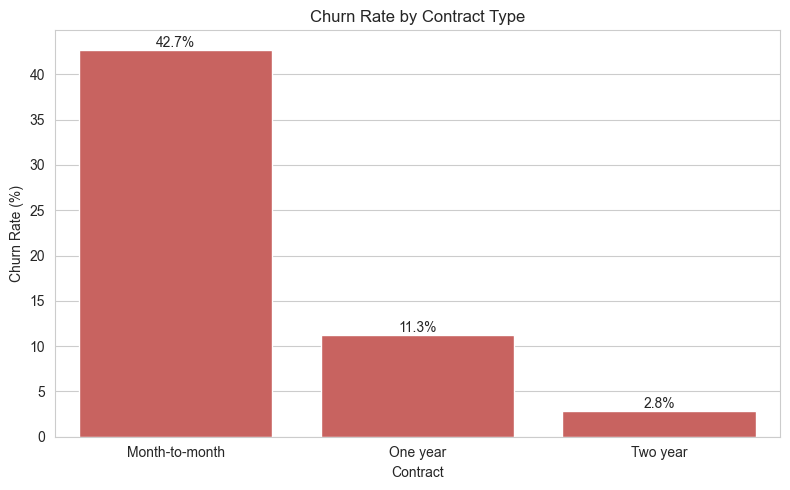

In [15]:
# set up clean styling
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 1. Compute churn rate per contract type
rate = (df.groupby("Contract")["Churn"]
          .apply(lambda s: (s == "Yes").mean() * 100)
          .reset_index())
rate.columns = ["Contract", "ChurnRate"]

# 2. Draw the bars (this is what creates "ax")
ax = sns.barplot(data=rate, x="Contract", y="ChurnRate", color="#d9534f")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")

# 3. Label each bar (your snippet — must come AFTER ax exists)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

# 4. Finish and display
plt.tight_layout()
plt.show()

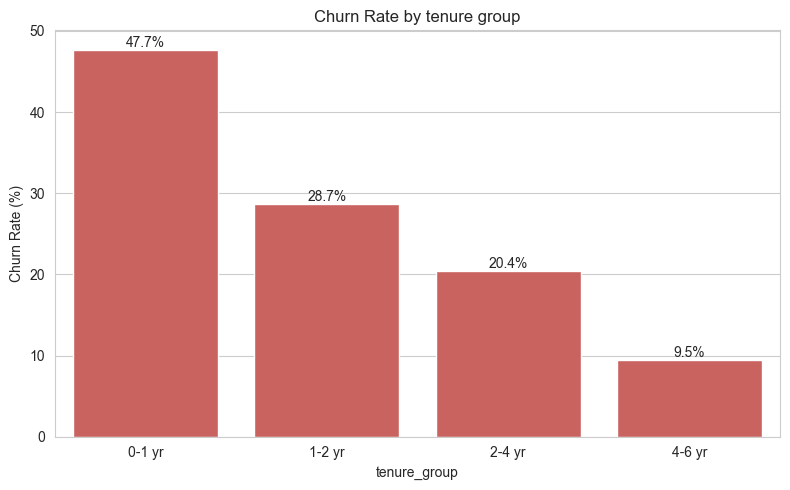

In [17]:
# set up clean styling
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 1. Compute churn rate per contract type
rate = (df.groupby("tenure_group")["Churn"]
          .apply(lambda s: (s == "Yes").mean() * 100)
          .reset_index())
rate.columns = ["tenure_group", "ChurnRate"]

# 2. Draw the bars (this is what creates "ax")
ax = sns.barplot(data=rate, x="tenure_group", y="ChurnRate", color="#d9534f")
plt.title("Churn Rate by tenure group")
plt.ylabel("Churn Rate (%)")

# 3. Label each bar (your snippet — must come AFTER ax exists)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

# 4. Finish and display
plt.tight_layout()
plt.show()